# 1st Hidden Layer — Evaluate Little-Perturbation Checkpoints

In the 1st-layer perturbation sweeps, models trained with a *little*
perturbation tend to score better at their matched evaluation level. This
notebook isolates that effect: for each perturbation type it loads a **single
checkpoint trained at a small perturbation level** and evaluates that one model
across the **entire** perturbation sweep (eval-on-checkpoint), rather than
training a fresh model per level.

Each perturbation is evaluated twice — once for the **no-delay** model and once
for the **delay** model — using the same checkpoint level:

- **Jitter** — per-spike Gaussian jitter; default checkpoint `sigma = 5`.
- **Shift** — per-neuron Gaussian shift; default checkpoint `sigma = 5`.
- **Deletion** — per-spike deletion; default checkpoint `p_d = 0.2`.

Evaluations cover the **whole / part / norm** SHD variants. The final section
plots the eval-on-checkpoint sweeps (read from `log_eval_on_perturbatedModel/`)
against the **no-perturbation** model (a checkpoint trained on the clean dataset
and evaluated across the whole sweep).

> **Note:** the first-layer **deletion** eval-on-checkpoint sweeps have not been
> generated yet, so that section is a placeholder that skips plotting until the
> `deletion_1stLayer_*_evalon_pd02.json` files exist.

In [5]:
# Setup: reuse the 2nd-layer training modules (model classes, data pipeline
# and evaluation routines) so the evaluation matches the original sweeps.
import sys
import json
from pathlib import Path

import numpy as np
import torch

BASE_DIR = Path.cwd()
assert (BASE_DIR / "jitter").is_dir(), (
    "Run this notebook from my_project/code/perturbation/ so the "
    "jitter / shift / deletion packages are importable."
)

for sub in ("jitter", "shift", "deletion"):
    sub_path = str((BASE_DIR / sub).resolve())
    if sub_path not in sys.path:
        sys.path.append(sub_path)

# Dataset variants to evaluate (matches result_visualization_2ndLayer.ipynb).
EVAL_DATASETS = ("whole", "part", "norm")

# Destination for the eval-on-checkpoint sweep results.
EVAL_LOG_DIR = Path("log_eval_on_perturbatedModel")
EVAL_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Eval results dir: {EVAL_LOG_DIR.resolve()}")

Eval results dir: D:\IC_2025\IRP\workspace\my_project\code\perturbation\log_eval_on_perturbatedModel


## 4. Comparison: little-perturbation checkpoint vs no-perturbation model

The two line styles encode the **training perturbation level** of the model
being swept:

- **Solid, &#9679;** — the little-perturbation checkpoint evaluated across all
  levels (read from `log_eval_on_perturbatedModel/`).
- **Dashed, &#10005;** — the **no-perturbation** model: a single checkpoint
  trained on the clean dataset and evaluated across the whole sweep. For jitter
  and shift this is the `{pert}/log/{pert}_{ds}_{delay}_{pert}_sweep_results.json`
  file (the first-layer `*_train.py` scripts train one clean model, then sweep
  the perturbation at evaluation time); for deletion it is the
  `deletion/log/deletion_{ds}_{delay}_evalOnly_deletion_sweep_results.json` file.

Dataset is encoded by colour (Whole / Part / Norm). For each perturbation a
**no-delay** plot and a **delay** plot are produced. Both curves are the *same*
model architecture evaluated over the identical sweep; they differ only in the
perturbation level the model saw during training (a little vs none), so the gap
between them isolates the effect of training with a small perturbation.

The **deletion** section is currently a placeholder: its first-layer
eval-on-checkpoint sweeps have not been generated yet.

In [7]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DS_LABEL = {"whole": "Whole", "part": "Part", "norm": "Norm"}


def load_sweep(path, key_type=int):
    """Load a sweep JSON -> (levels, means_pct, stds_pct)."""
    with open(path) as fh:
        raw = json.load(fh)
    levels = sorted(key_type(k) for k in raw)
    means = np.array([raw[str(lvl)]["mean"] for lvl in levels]) * 100
    stds = np.array([raw[str(lvl)]["std"] for lvl in levels]) * 100
    return levels, means, stds


def plot_comparison(new_paths, old_paths, key_type, xlabel, title, xlim,
                    checkpoint_label):
    """Overlay eval-on-checkpoint (solid) vs no-perturbation model (dashed)."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for ds in EVAL_DATASETS:
        color = COLORS[DS_LABEL[ds]]

        nx, nm, nsd = load_sweep(new_paths[ds], key_type)
        ax.plot(nx, nm, "o-", color=color, markersize=5, linewidth=1.8)
        ax.fill_between(nx, nm - nsd, nm + nsd, color=color, alpha=0.12)

        ox, om, osd = load_sweep(old_paths[ds], key_type)
        ax.plot(ox, om, "x--", color=color, markersize=6, linewidth=1.8)
        ax.fill_between(ox, om - osd, om + osd, color=color, alpha=0.08)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

    h_new = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                          markersize=5, linewidth=1.8,
                          label=f"Eval-on-ckpt ({checkpoint_label})")
    h_old = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                          markersize=6, linewidth=1.8,
                          label="Trained @ no perturbation")
    h_w = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
    h_p = mlines.Line2D([], [], color=COLORS["Part"], linewidth=2.5, label="Part")
    h_n = mlines.Line2D([], [], color=COLORS["Norm"], linewidth=2.5, label="Norm")
    ax.legend(handles=[h_new, h_old, h_w, h_p, h_n], loc="best",
              framealpha=0.9, ncol=2)

    fig.tight_layout()
    plt.show()
    return fig

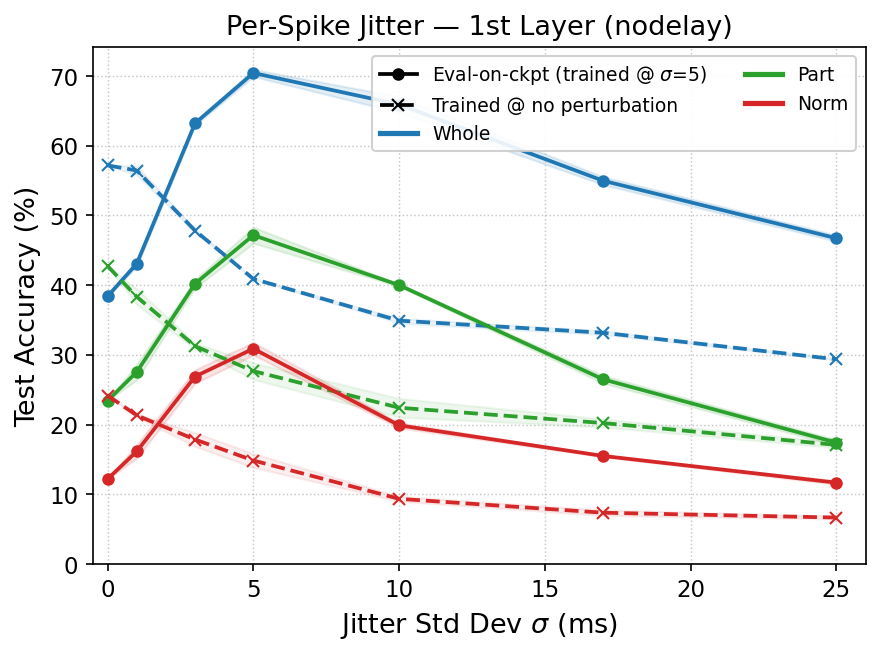

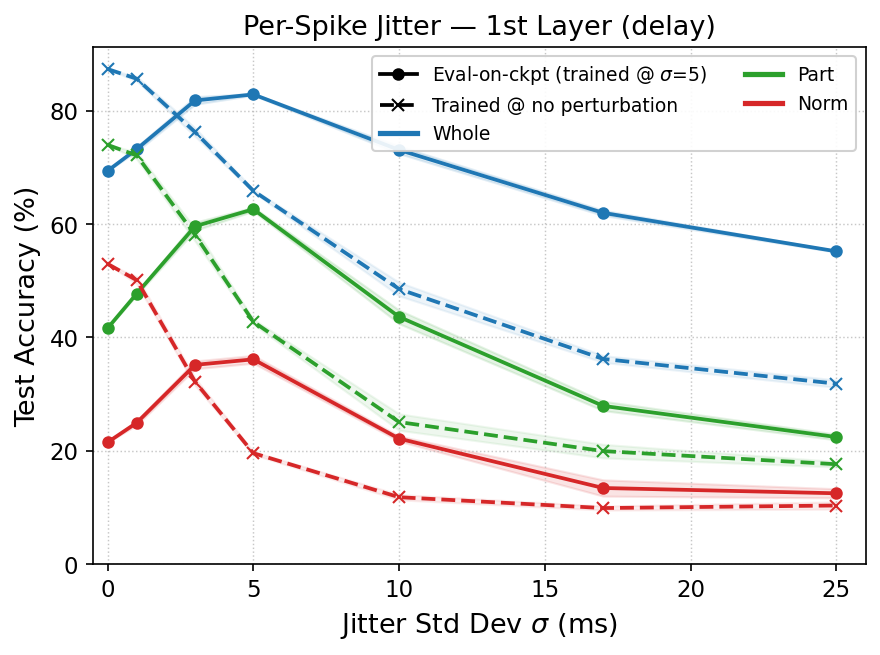

In [10]:
CHECKPOINT_SIGMA_JITTER = 5
for delay_tag in ("nodelay", "delay"):
    token = f"sigma{CHECKPOINT_SIGMA_JITTER}"
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"jitter_1stLayer_{ds}_{delay_tag}_evalon_{token}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("jitter/log")
        / f"jitter_{ds}_{delay_tag}_jitter_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    plot_comparison(
        new_paths, old_paths, int,
        xlabel=r"Jitter Std Dev $\sigma$ (ms)",
        title=f"Per-Spike Jitter — 1st Layer ({delay_tag})",
        xlim=(-0.5, 26),
        checkpoint_label=rf"trained @ $\sigma$={CHECKPOINT_SIGMA_JITTER}",
    )

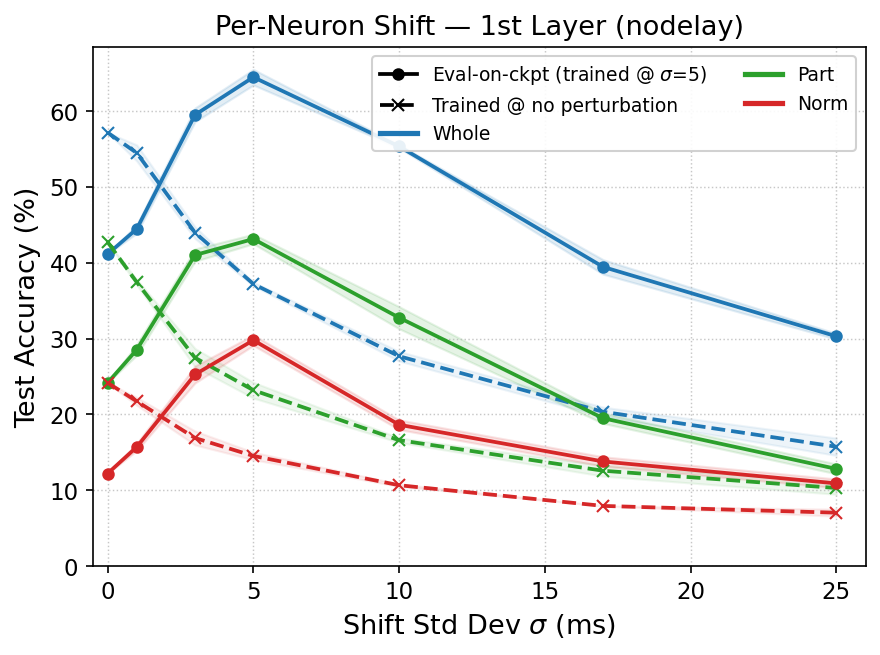

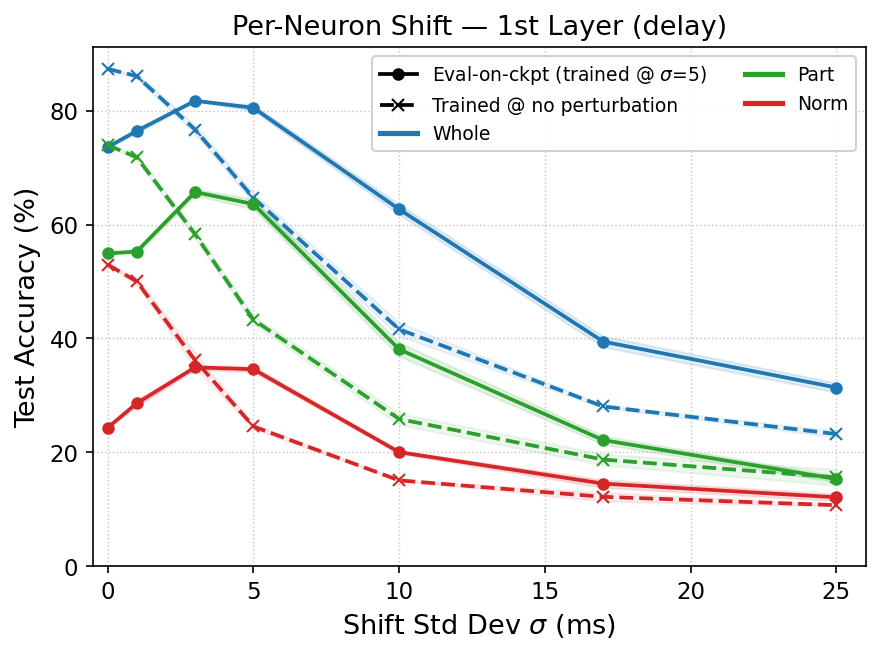

In [11]:
CHECKPOINT_SIGMA_SHIFT = 5
for delay_tag in ("nodelay", "delay"):
    token = f"sigma{CHECKPOINT_SIGMA_SHIFT}"
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"shift_1stLayer_{ds}_{delay_tag}_evalon_{token}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("shift/log")
        / f"shift_{ds}_{delay_tag}_shift_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    plot_comparison(
        new_paths, old_paths, int,
        xlabel=r"Shift Std Dev $\sigma$ (ms)",
        title=f"Per-Neuron Shift — 1st Layer ({delay_tag})",
        xlim=(-0.5, 26),
        checkpoint_label=rf"trained @ $\sigma$={CHECKPOINT_SIGMA_SHIFT}",
    )

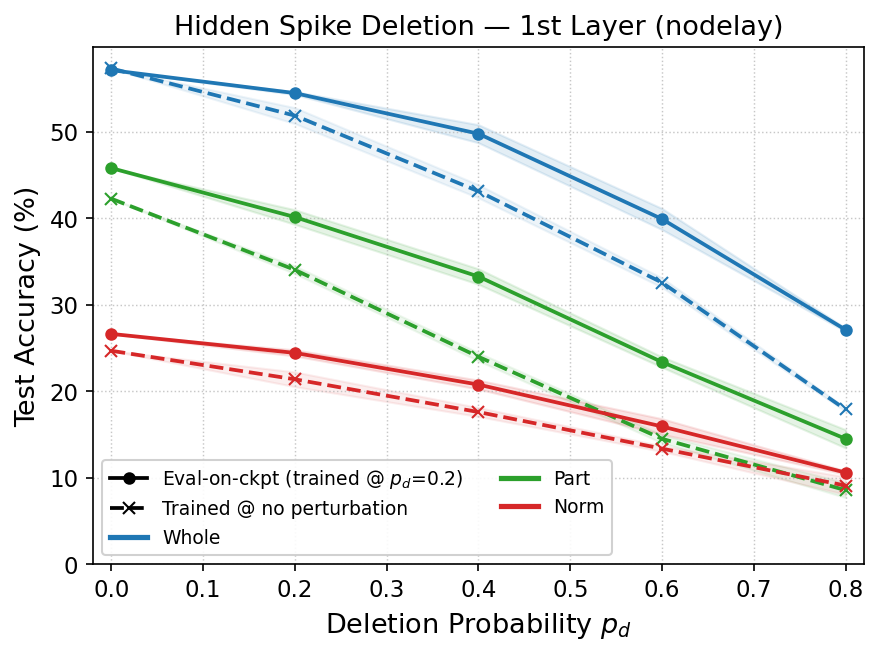

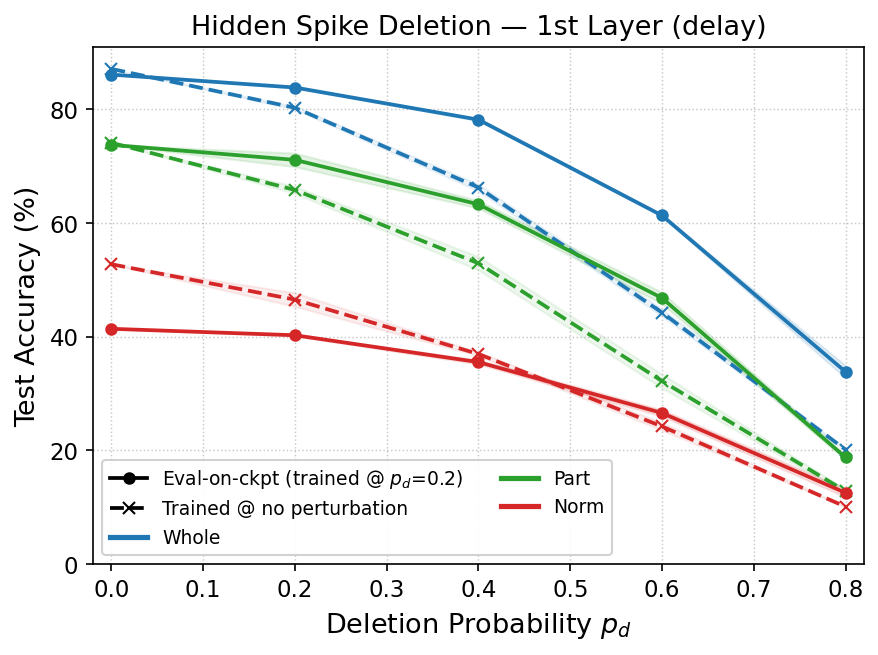

In [8]:
# PLACEHOLDER — first-layer deletion eval-on-checkpoint sweeps are not yet
# available. The eval-on-checkpoint results (solid line) live in
# log_eval_on_perturbatedModel/deletion_1stLayer_{ds}_{delay}_evalon_pd02.json
# and have not been generated. This cell skips plotting (with a message) until
# those files exist; the dashed no-perturbation curve is already available in
# deletion/log/. Once the eval-on-checkpoint files are produced, this cell will
# render the comparison automatically.
CHECKPOINT_PD_DELETION = 0.2
_pd_token_plot = f"pd{int(round(CHECKPOINT_PD_DELETION * 10)):02d}"
for delay_tag in ("nodelay", "delay"):
    new_paths = {
        ds: EVAL_LOG_DIR
        / f"deletion_1stLayer_{ds}_{delay_tag}_evalon_{_pd_token_plot}.json"
        for ds in EVAL_DATASETS
    }
    old_paths = {
        ds: Path("deletion/log")
        / f"deletion_{ds}_{delay_tag}_evalOnly_deletion_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    missing = [str(p) for p in new_paths.values() if not p.exists()]
    if missing:
        print(f"[deletion/{delay_tag}] PLACEHOLDER — skipped; "
              f"eval-on-checkpoint results not found:")
        for path in missing:
            print(f"    missing: {path}")
        continue
    plot_comparison(
        new_paths, old_paths, float,
        xlabel=r"Deletion Probability $p_d$",
        title=f"Hidden Spike Deletion — 1st Layer ({delay_tag})",
        xlim=(-0.02, 0.82),
        checkpoint_label=rf"trained @ $p_d$={CHECKPOINT_PD_DELETION}",
    )